In [1]:
!pip install lightgbm xgboost shap optuna imbalanced-learn plotly streamlit scikit-learn pandas numpy matplotlib seaborn --quiet


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

train_transaction = pd.read_csv('data/train_transaction.csv')
train_identity    = pd.read_csv('data/train_identity.csv')

df = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')

print(f'Merged Dataset Shape: {df.shape}')
print(f'\nData Types:\n{df.dtypes.value_counts()}')
df.head(10)

Merged Dataset Shape: (590540, 434)

Data Types:
float64    399
str         31
int64        4
Name: count, dtype: int64


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
5,2987005,0,86510,49.0,W,5937,555.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2987006,0,86522,159.0,W,12308,360.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,2987007,0,86529,422.5,W,12695,490.0,150.0,visa,226.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,2987008,0,86535,15.0,H,2803,100.0,150.0,visa,226.0,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
9,2987009,0,86536,117.0,W,17399,111.0,150.0,mastercard,224.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


          Count  Percentage
isFraud                    
0        569877        96.5
1         20663         3.5


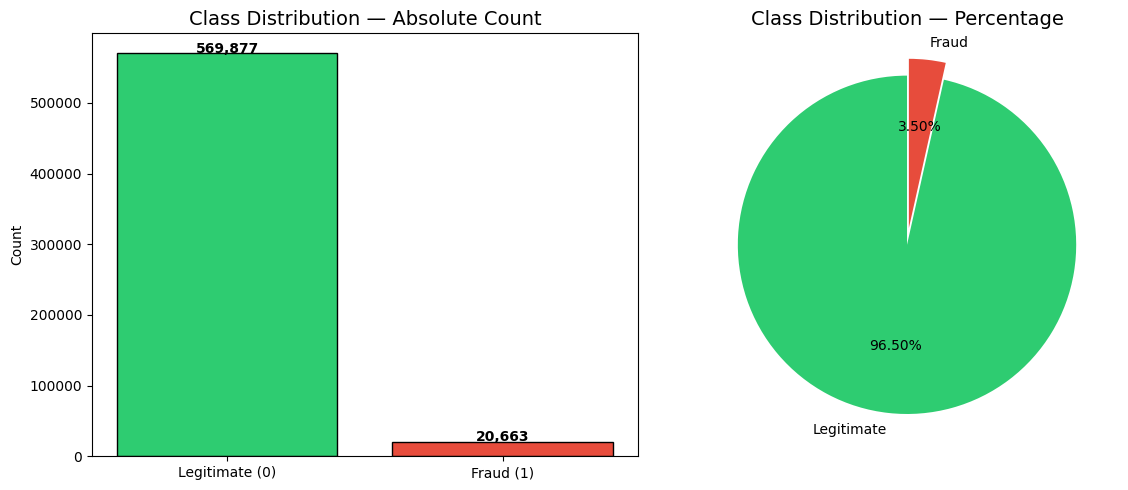

In [3]:
fraud_counts = df['isFraud'].value_counts()
fraud_pct    = df['isFraud'].value_counts(normalize=True) * 100

print(pd.DataFrame({'Count': fraud_counts, 'Percentage': fraud_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['Legitimate (0)', 'Fraud (1)'], fraud_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Class Distribution — Absolute Count', fontsize=14)
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.2f%%',
            startangle=90, explode=(0, 0.1))
axes[1].set_title('Class Distribution — Percentage', fontsize=14)

plt.tight_layout()
plt.savefig('charts/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df  = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct.round(2)})
missing_df  = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f'Columns with missing values: {len(missing_df)}')
print(f'Columns to DROP (>50% missing): {(missing_df["Missing %"] > 50).sum()}')
print(f'Columns to IMPUTE (<=50% missing): {(missing_df["Missing %"] <= 50).sum()}')
missing_df.head(20)

Columns with missing values: 414
Columns to DROP (>50% missing): 214
Columns to IMPUTE (<=50% missing): 200


,Missing Count,Missing %
id_24,585793,99.20
id_07,585385,99.13
id_25,585408,99.13
id_08,585385,99.13
id_26,585377,99.13
id_21,585381,99.13
id_23,585371,99.12
id_22,585371,99.12
id_27,585371,99.12
dist2,552913,93.63


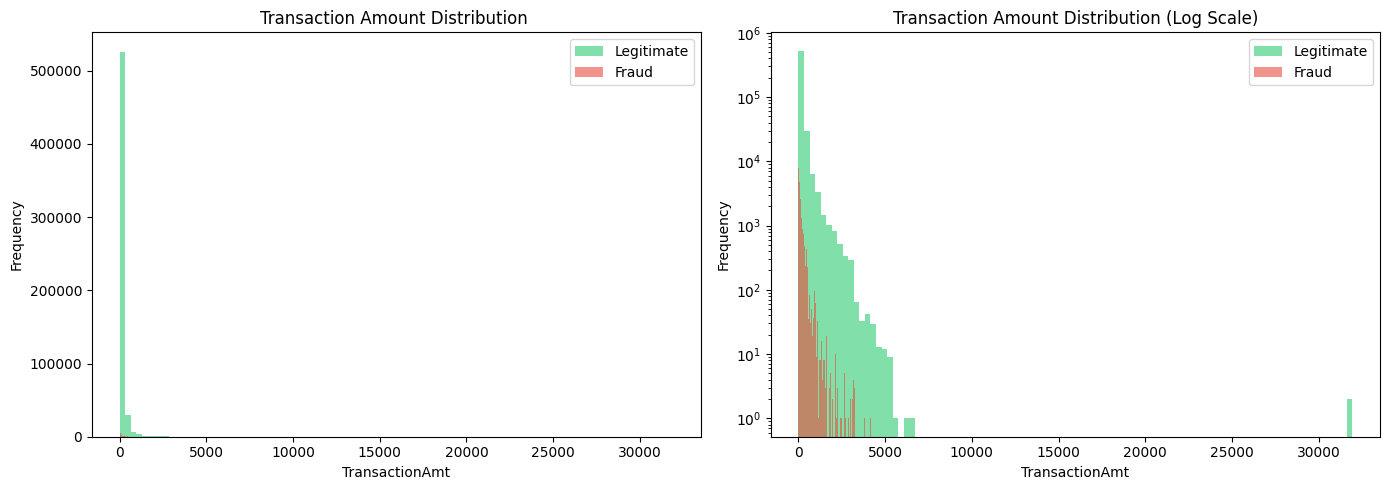

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, log in zip(axes, [False, True]):
    for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
        data = df[df['isFraud'] == label]['TransactionAmt']
        ax.hist(data, bins=100, alpha=0.6, color=color,
                label='Legitimate' if label == 0 else 'Fraud', log=log)
    ax.set_xlabel('TransactionAmt')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Transaction Amount Distribution {"(Log Scale)" if log else ""}')
    ax.legend()

plt.tight_layout()
plt.savefig('charts/transaction_amt_dist.png', dpi=150, bbox_inches='tight')
plt.show()

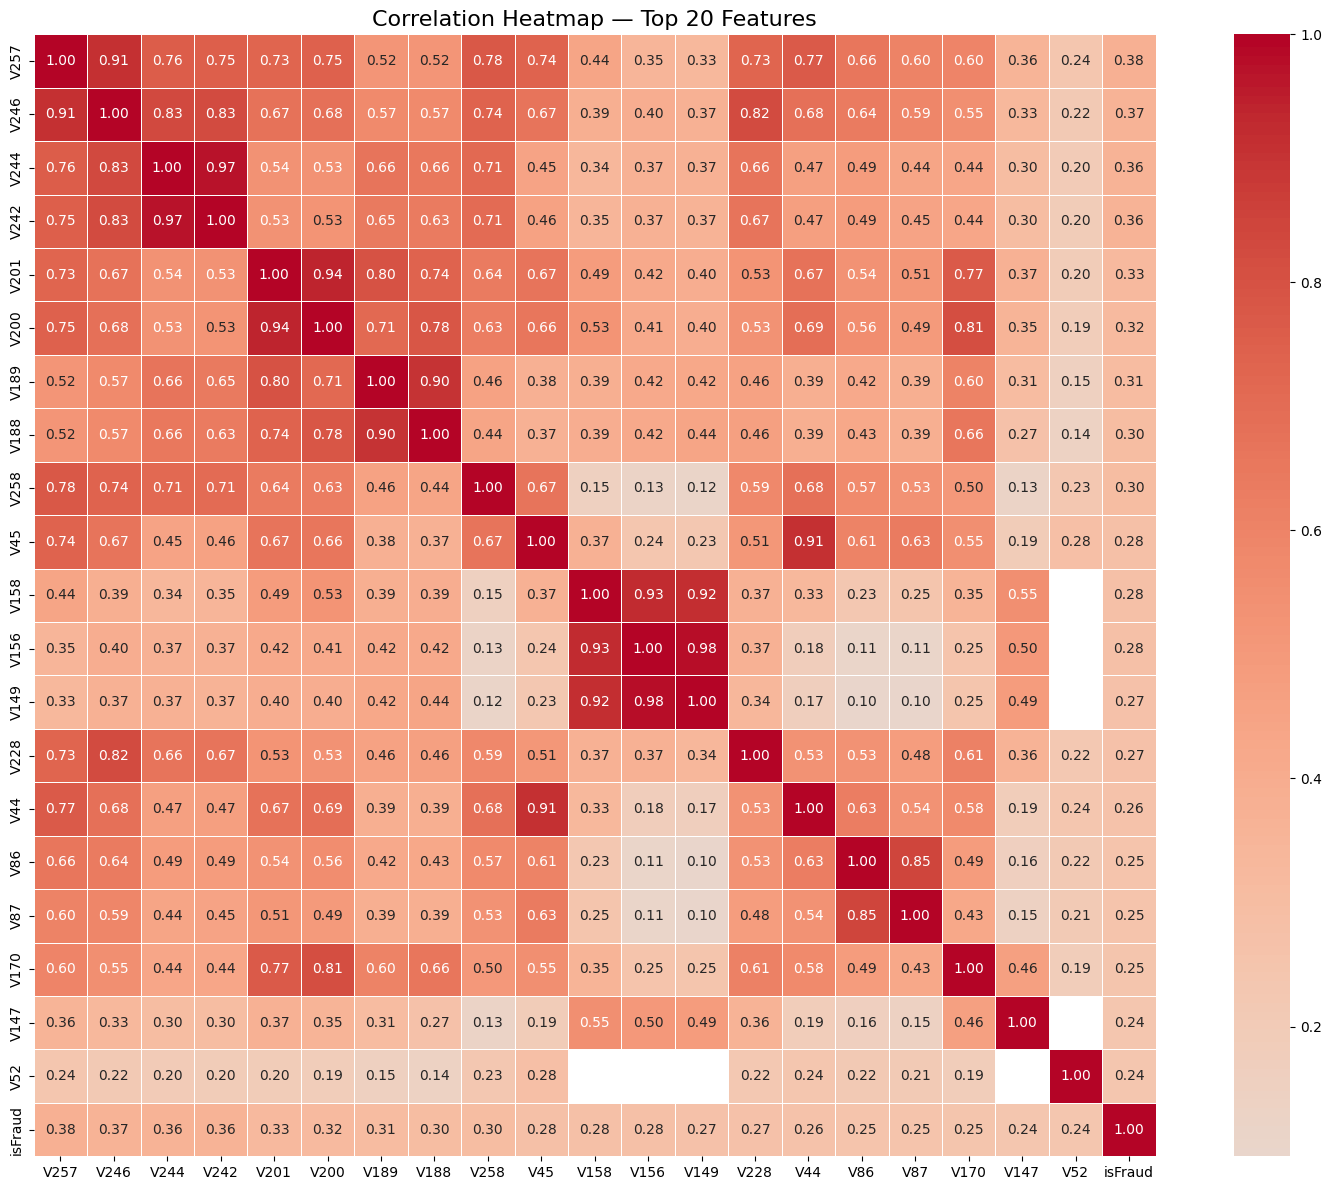

In [6]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
top20    = df[num_cols].corr()['isFraud'].abs().sort_values(ascending=False).head(21).index.tolist()
top20    = [c for c in top20 if c != 'isFraud'][:20]

corr_matrix = df[top20 + ['isFraud']].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Top 20 Features', fontsize=16)
plt.tight_layout()
plt.savefig('charts/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np

# ── Step 1: Drop >50% missing columns (safe - ignores already dropped) ──
drop_cols = missing_df[missing_df['Missing %'] > 50].index.tolist()
drop_cols = [c for c in drop_cols if c in df.columns]  # only drop if still exists
df.drop(columns=drop_cols, inplace=True)
print(f'Dropped {len(drop_cols)} columns. Remaining shape: {df.shape}')

# ── Step 2: Feature Engineering ──
if 'AmtToMeanRatio' not in df.columns:
    df['AmtToMeanRatio']    = df['TransactionAmt'] / df['TransactionAmt'].mean()
    df['HourOfDay']         = (df['TransactionDT'] // 3600) % 24
    df['DayOfWeek']         = (df['TransactionDT'] // (3600 * 24)) % 7
    df['LogTransactionAmt'] = np.log1p(df['TransactionAmt'])
    print('Feature engineering done.')
else:
    print('Features already exist, skipping.')

# ── Step 3: Encode categoricals ──
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns.tolist()
            if c not in ['isFraud', 'TransactionID']]

le = LabelEncoder()
for col in cat_cols:
    df[col].fillna('missing', inplace=True)
    df[col] = le.fit_transform(df[col].astype(str))

# ── Step 4: Impute all remaining NaNs ──
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

df.fillna(df.median(numeric_only=True), inplace=True)
print(f'Remaining NaNs: {df.isnull().sum().sum()}')

# ── Step 5: Train/Test Split ──
feature_cols = [c for c in df.columns if c not in ['isFraud', 'TransactionID']]
X = df[feature_cols]
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'\nClass ratio BEFORE SMOTE:\n{y_train.value_counts(normalize=True).round(4)}')

# ── Step 6: Scale ──
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ── Step 7: Fix any NaN/Inf before SMOTE ──
X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
X_test_scaled  = np.nan_to_num(X_test_scaled,  nan=0.0, posinf=0.0, neginf=0.0)

print(f'NaNs in training data: {np.isnan(X_train_scaled).sum()}')

# ── Step 8: SMOTE ──
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f'\nClass ratio AFTER SMOTE:\n{pd.Series(y_train_res).value_counts(normalize=True).round(4)}')
print(f'Resampled training size: {X_train_res.shape}')

Dropped 214 columns. Remaining shape: (590540, 220)
Feature engineering done.
Remaining NaNs: 0
Train: (472432, 222) | Test: (118108, 222)

Class ratio BEFORE SMOTE:
isFraud
0    0.965
1    0.035
Name: proportion, dtype: float64
NaNs in training data: 0

Class ratio AFTER SMOTE:
isFraud
0    0.5
1    0.5
Name: proportion, dtype: float64
Resampled training size: (911804, 222)


In [8]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score,
                              confusion_matrix, roc_curve, precision_recall_curve)
import pickle

def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1-Score' : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC-AUC'  : round(roc_auc_score(y_true, y_prob), 4),
        'PR-AUC'   : round(average_precision_score(y_true, y_prob), 4)
    }

results = []

# LightGBM
lgbm = LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=63, random_state=42, n_jobs=-1)
lgbm.fit(X_train_res, y_train_res)
lgbm_prob = lgbm.predict_proba(X_test_scaled)[:, 1]
lgbm_pred = (lgbm_prob >= 0.5).astype(int)
results.append(evaluate_model('LightGBM', y_test, lgbm_pred, lgbm_prob))
print('LightGBM done.')

# XGBoost
xgb = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=6,
                     random_state=42, n_jobs=-1, eval_metric='logloss', use_label_encoder=False)
xgb.fit(X_train_res, y_train_res)
xgb_prob = xgb.predict_proba(X_test_scaled)[:, 1]
xgb_pred = (xgb_prob >= 0.5).astype(int)
results.append(evaluate_model('XGBoost', y_test, xgb_pred, xgb_prob))
print('XGBoost done.')

# Isolation Forest
iso      = IsolationForest(contamination=0.035, random_state=42, n_jobs=-1)
iso.fit(X_train_scaled)
iso_raw  = iso.decision_function(X_test_scaled)
iso_prob = 1 - (iso_raw - iso_raw.min()) / (iso_raw.max() - iso_raw.min())
iso_pred = (iso.predict(X_test_scaled) == -1).astype(int)
results.append(evaluate_model('IsolationForest', y_test, iso_pred, iso_prob))
print('IsolationForest done.')

results_df = pd.DataFrame(results).set_index('Model')
results_df

[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.841577 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 53602
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 220
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM done.
XGBoost done.
IsolationForest done.


,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC
Model,,,,,,
LightGBM,0.9803,0.8910,0.4965,0.6377,0.9481,0.7297
XGBoost,0.9774,0.8296,0.4442,0.5786,0.9134,0.6140
IsolationForest,0.9425,0.1829,0.1858,0.1843,0.7056,0.1062


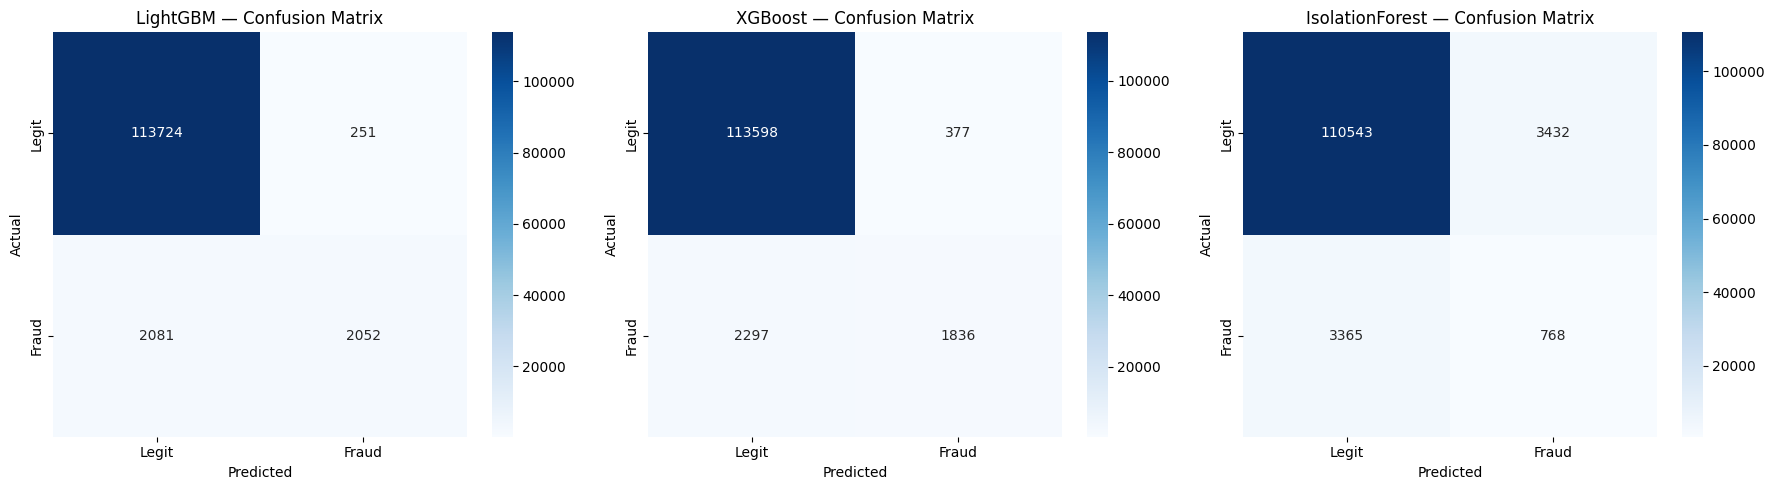

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
models_info = [
    ('LightGBM',        y_test, lgbm_pred),
    ('XGBoost',         y_test, xgb_pred),
    ('IsolationForest', y_test, iso_pred)
]
for ax, (name, yt, yp) in zip(axes, models_info):
    cm = confusion_matrix(yt, yp)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
    ax.set_title(f'{name} — Confusion Matrix')
    ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('charts/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

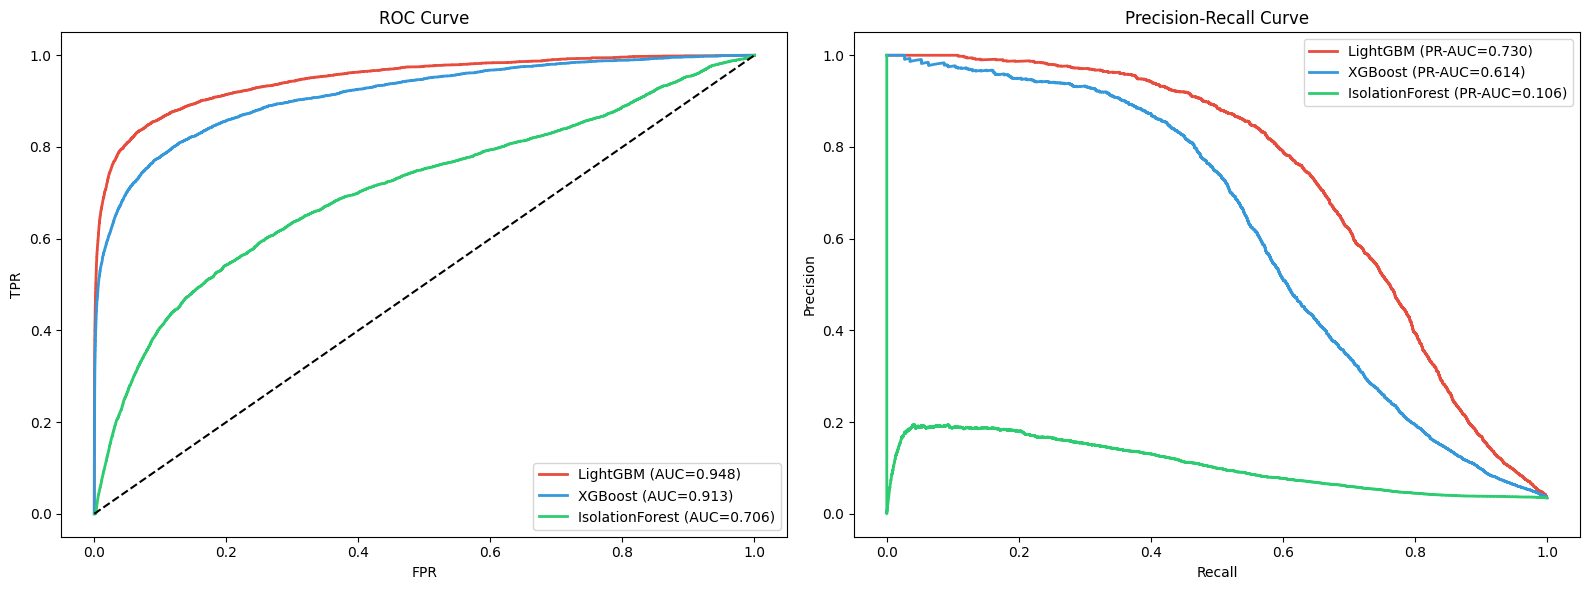

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
probs = [('LightGBM', lgbm_prob, '#e74c3c'),
         ('XGBoost',  xgb_prob,  '#3498db'),
         ('IsolationForest', iso_prob, '#2ecc71')]

for name, prob, color in probs:
    fpr, tpr, _ = roc_curve(y_test, prob)
    axes[0].plot(fpr, tpr, color=color, label=f'{name} (AUC={roc_auc_score(y_test,prob):.3f})', lw=2)

    p, r, _ = precision_recall_curve(y_test, prob)
    axes[1].plot(r, p, color=color, label=f'{name} (PR-AUC={average_precision_score(y_test,prob):.3f})', lw=2)

axes[0].plot([0,1],[0,1],'k--')
axes[0].set_title('ROC Curve'); axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend()
axes[1].set_title('Precision-Recall Curve'); axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision'); axes[1].legend()

plt.tight_layout()
plt.savefig('charts/roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

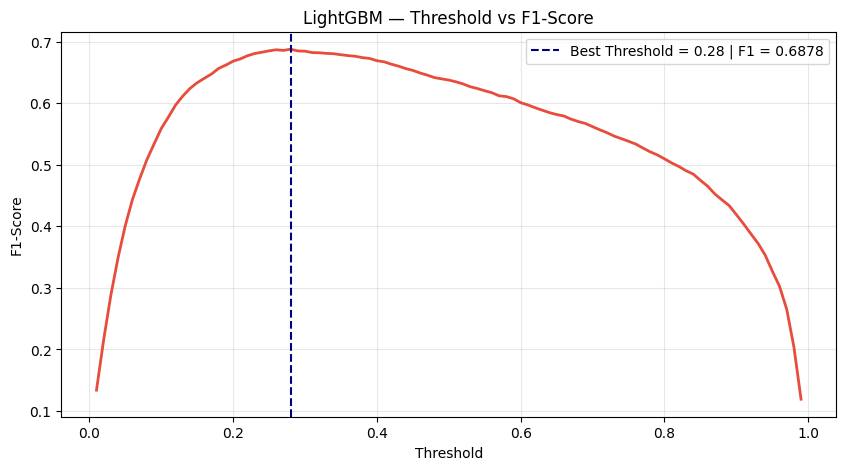

Optimal Threshold: 0.28


In [11]:
thresholds = np.arange(0.01, 1.0, 0.01)
f1_scores  = [f1_score(y_test, (lgbm_prob >= t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]

plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores, color='#e74c3c', lw=2)
plt.axvline(best_thresh, color='navy', linestyle='--',
            label=f'Best Threshold = {best_thresh:.2f} | F1 = {max(f1_scores):.4f}')
plt.xlabel('Threshold'); plt.ylabel('F1-Score')
plt.title('LightGBM — Threshold vs F1-Score')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('charts/threshold_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Optimal Threshold: {best_thresh:.2f}')

In [13]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Use only a SAMPLE of training data for tuning (much faster)
from sklearn.utils import resample

sample_size = 50000  # use 50k instead of 900k rows
idx = resample(range(len(X_train_res)), n_samples=sample_size, random_state=42)
X_tune = X_train_res[idx]
y_tune = y_train_res[idx]

def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 200),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.05, 0.2),
        'num_leaves'       : trial.suggest_int('num_leaves', 31, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 20, 50),
        'subsample'        : trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'random_state'     : 42,
        'n_jobs'           : -1,
        'verbose'          : -1,
        'force_col_wise'   : True   # removes threading overhead warning
    }
    model = LGBMClassifier(**params)
    model.fit(X_tune, y_tune)
    prob = model.predict_proba(X_test_scaled)[:, 1]
    return roc_auc_score(y_test, prob)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=5, show_progress_bar=True)  # only 5 trials

print(f'Best ROC-AUC: {study.best_value:.4f}')
print(f'Best Params : {study.best_params}')

# Retrain best model on FULL data
best_lgbm = LGBMClassifier(**study.best_params, verbose=-1, force_col_wise=True)
best_lgbm.fit(X_train_res, y_train_res)
best_prob = best_lgbm.predict_proba(X_test_scaled)[:, 1]
best_pred = (best_prob >= best_thresh).astype(int)
print(pd.DataFrame([evaluate_model('Tuned LightGBM', y_test, best_pred, best_prob)]))

with open('dashboard/model.pkl', 'wb') as f:
    pickle.dump({'model': best_lgbm, 'scaler': scaler,
                 'features': feature_cols, 'threshold': best_thresh}, f)
print('Model saved!')

Best trial: 3. Best value: 0.904247: 100%|███████████████████████████████████████████████| 5/5 [00:35<00:00,  7.17s/it]


Best ROC-AUC: 0.9042
Best Params : {'n_estimators': 179, 'learning_rate': 0.08501377104618184, 'num_leaves': 57, 'min_child_samples': 36, 'subsample': 0.9532283452844178, 'colsample_bytree': 0.9054808643424708}
            Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
0  Tuned LightGBM    0.9756      0.682  0.5676    0.6196     0.93  0.6558
Model saved!


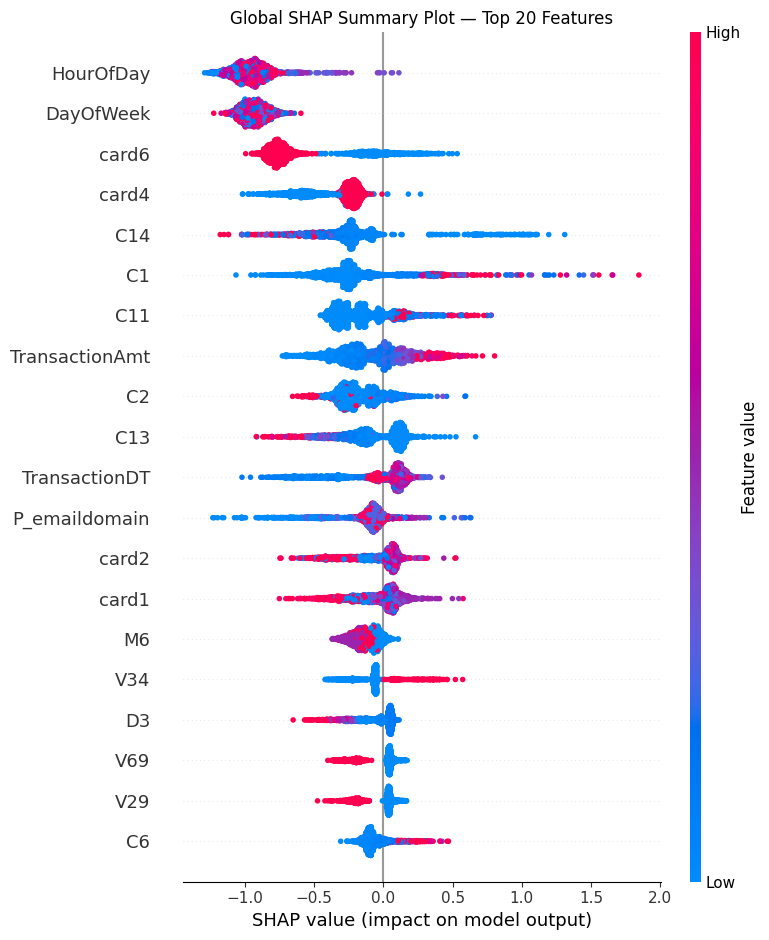

In [14]:
import shap
shap.initjs()

explainer    = shap.TreeExplainer(best_lgbm)
X_test_df    = pd.DataFrame(X_test_scaled[:2000], columns=feature_cols)
shap_values  = explainer.shap_values(X_test_df)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

# Global Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(sv, X_test_df, max_display=20, show=False)
plt.title('Global SHAP Summary Plot — Top 20 Features')
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.savefig('charts/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

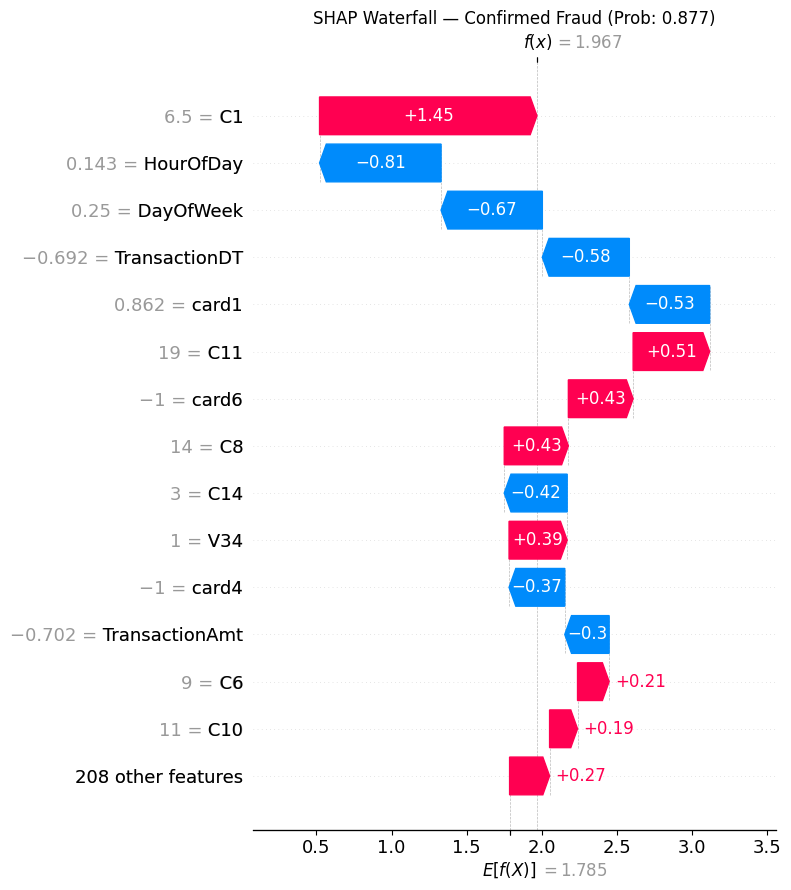

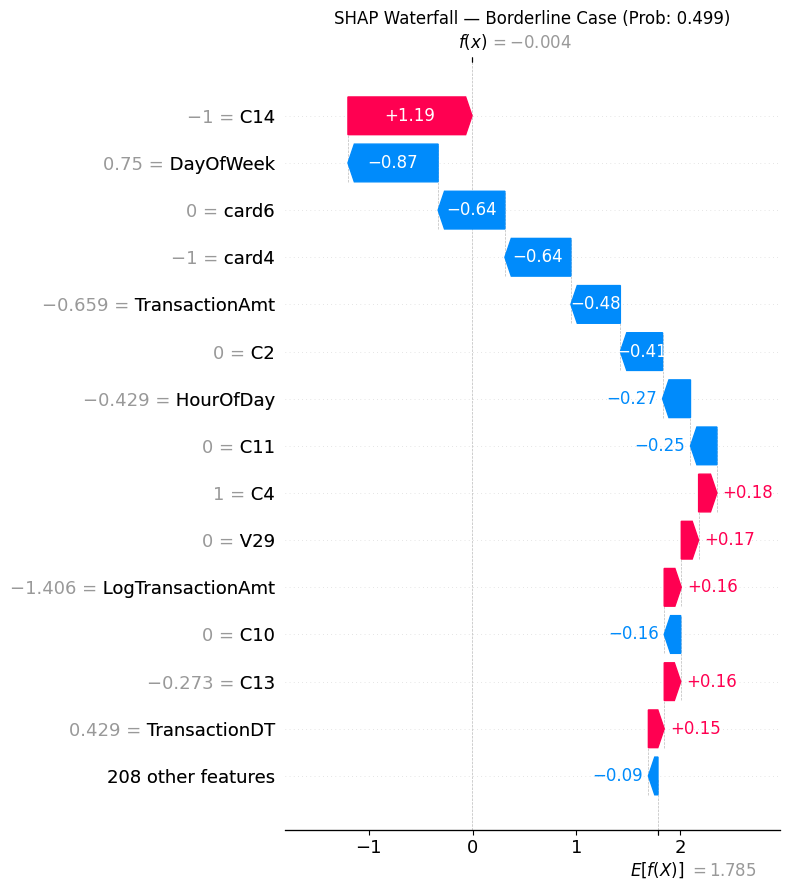

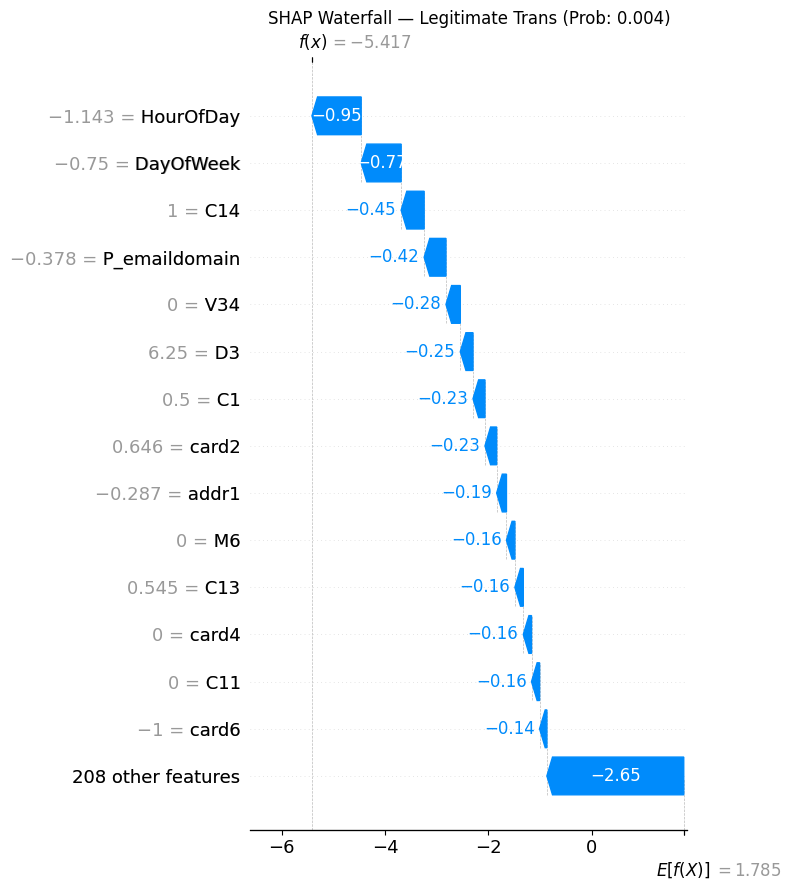

In [15]:
probs_sample = best_prob[:2000]

fraud_idx      = np.where((y_test.values[:2000] == 1) & (probs_sample >= 0.75))[0]
borderline_idx = np.where((probs_sample >= 0.45) & (probs_sample <= 0.55))[0]
legit_idx      = np.where((y_test.values[:2000] == 0) & (probs_sample < 0.1))[0]

base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, list) else explainer.expected_value
exp = shap.Explanation(values=sv, base_values=base_val,
                        data=X_test_df.values, feature_names=feature_cols)

cases = [
    ('Confirmed Fraud',   fraud_idx[0]      if len(fraud_idx) > 0      else 0),
    ('Borderline Case',   borderline_idx[0] if len(borderline_idx) > 0 else 1),
    ('Legitimate Trans',  legit_idx[0]      if len(legit_idx) > 0      else 2),
]

for title, idx in cases:
    plt.figure(figsize=(12, 5))
    shap.waterfall_plot(exp[idx], max_display=15, show=False)
    plt.title(f'SHAP Waterfall — {title} (Prob: {probs_sample[idx]:.3f})')
    plt.tight_layout()
    fname = title.lower().replace(' ', '_').replace('.', '')
    plt.savefig(f'charts/shap_waterfall_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

<Figure size 1000x600 with 0 Axes>

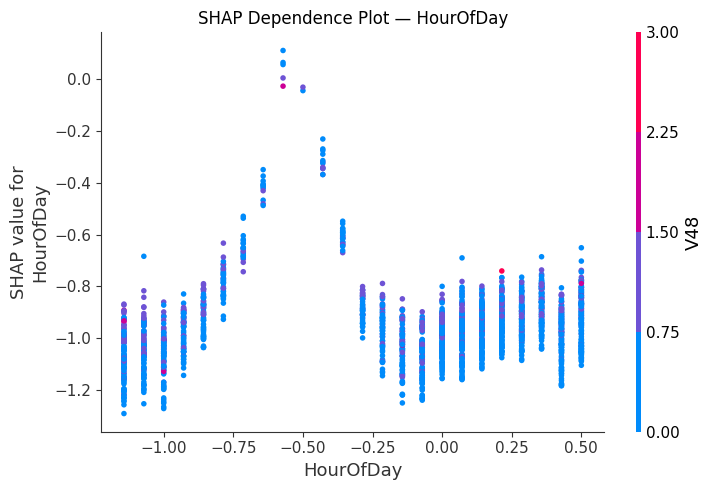

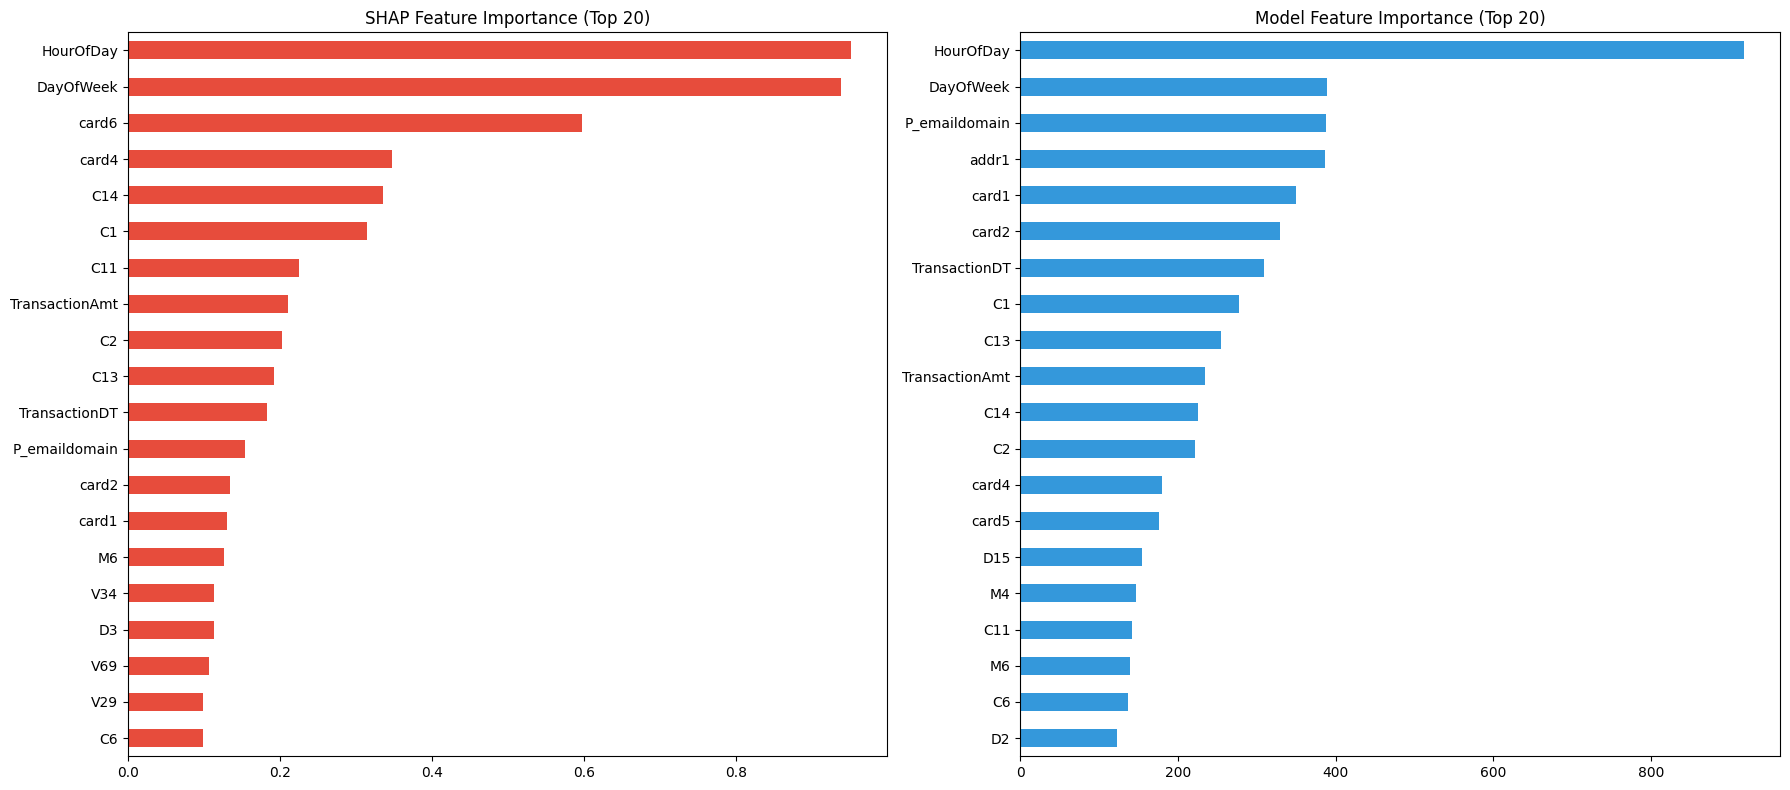

In [16]:
# Dependence Plot
top_feature = pd.DataFrame(sv, columns=feature_cols).abs().mean().idxmax()
plt.figure(figsize=(10, 6))
shap.dependence_plot(top_feature, sv, X_test_df, show=False)
plt.title(f'SHAP Dependence Plot — {top_feature}')
plt.tight_layout()
plt.savefig('charts/shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

# SHAP vs Model Importance
shap_imp  = pd.Series(np.abs(sv).mean(axis=0), index=feature_cols).sort_values(ascending=False).head(20)
model_imp = pd.Series(best_lgbm.feature_importances_, index=feature_cols).sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
shap_imp.plot(kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('SHAP Feature Importance (Top 20)'); axes[0].invert_yaxis()
model_imp.plot(kind='barh', ax=axes[1], color='#3498db')
axes[1].set_title('Model Feature Importance (Top 20)'); axes[1].invert_yaxis()
plt.tight_layout()
plt.savefig('charts/feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
test_df = X_test.copy().reset_index(drop=True)
test_df['FraudProb'] = best_prob
test_df['isFraud']   = y_test.values
test_df['Predicted'] = best_pred

def assign_risk(p):
    if p >= 0.75:   return 'Critical Risk'
    elif p >= 0.40: return 'Suspicious'
    return 'Clear'

test_df['RiskTier'] = test_df['FraudProb'].apply(assign_risk)

tier_summary = test_df.groupby('RiskTier').agg(
    Count=('FraudProb','count'),
    Avg_TransactionAmt=('TransactionAmt','mean'),
    Fraud_Rate=('isFraud','mean')
).round(4)
print(tier_summary)

                Count  Avg_TransactionAmt  Fraud_Rate
RiskTier                                             
Clear          115526            134.9716      0.0179
Critical Risk    1453            104.3926      0.9326
Suspicious       1129            161.4814      0.6289


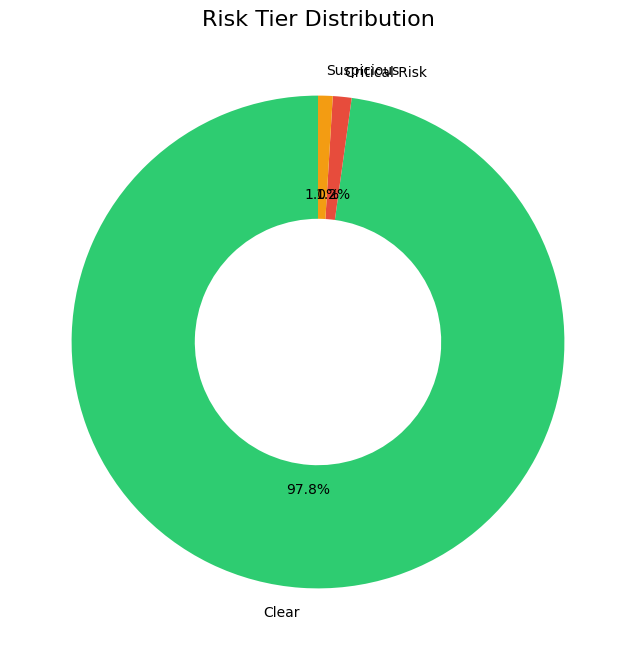

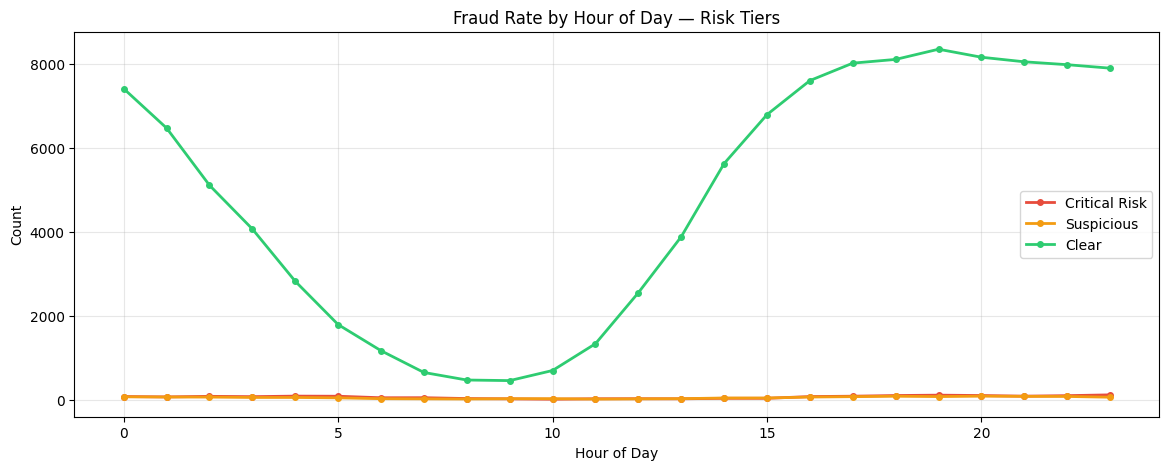

In [18]:
colors = {'Critical Risk': '#e74c3c', 'Suspicious': '#f39c12', 'Clear': '#2ecc71'}

# Donut chart
tier_counts = test_df['RiskTier'].value_counts()
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(tier_counts.values, labels=tier_counts.index,
       colors=[colors[t] for t in tier_counts.index],
       autopct='%1.1f%%', startangle=90, wedgeprops=dict(width=0.5))
ax.set_title('Risk Tier Distribution', fontsize=16)
plt.savefig('charts/risk_tier_donut.png', dpi=150, bbox_inches='tight')
plt.show()

# Hour of day by tier
plt.figure(figsize=(14, 5))
for tier, color in colors.items():
    subset = test_df[test_df['RiskTier'] == tier]
    hour_counts = subset['HourOfDay'].value_counts().sort_index()
    plt.plot(hour_counts.index, hour_counts.values, label=tier, color=color, lw=2, marker='o', ms=4)
plt.xlabel('Hour of Day'); plt.ylabel('Count')
plt.title('Fraud Rate by Hour of Day — Risk Tiers')
plt.legend(); plt.grid(alpha=0.3)
plt.savefig('charts/fraud_rate_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

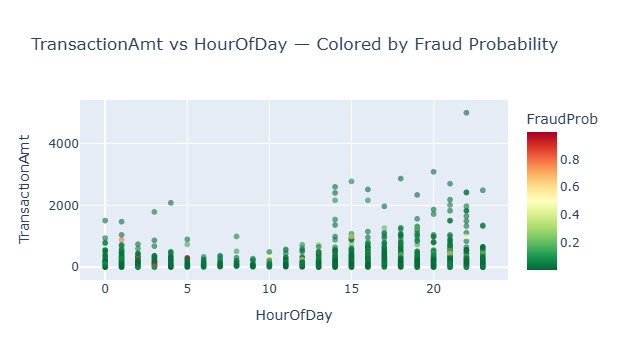

In [19]:
import plotly.express as px

sample_plot = test_df.sample(min(5000, len(test_df)), random_state=42)

fig = px.scatter(
    sample_plot, x='HourOfDay', y='TransactionAmt',
    color='FraudProb', color_continuous_scale='RdYlGn_r',
    opacity=0.6, title='TransactionAmt vs HourOfDay — Colored by Fraud Probability',
    hover_data=['FraudProb', 'RiskTier']
)
fig.show()

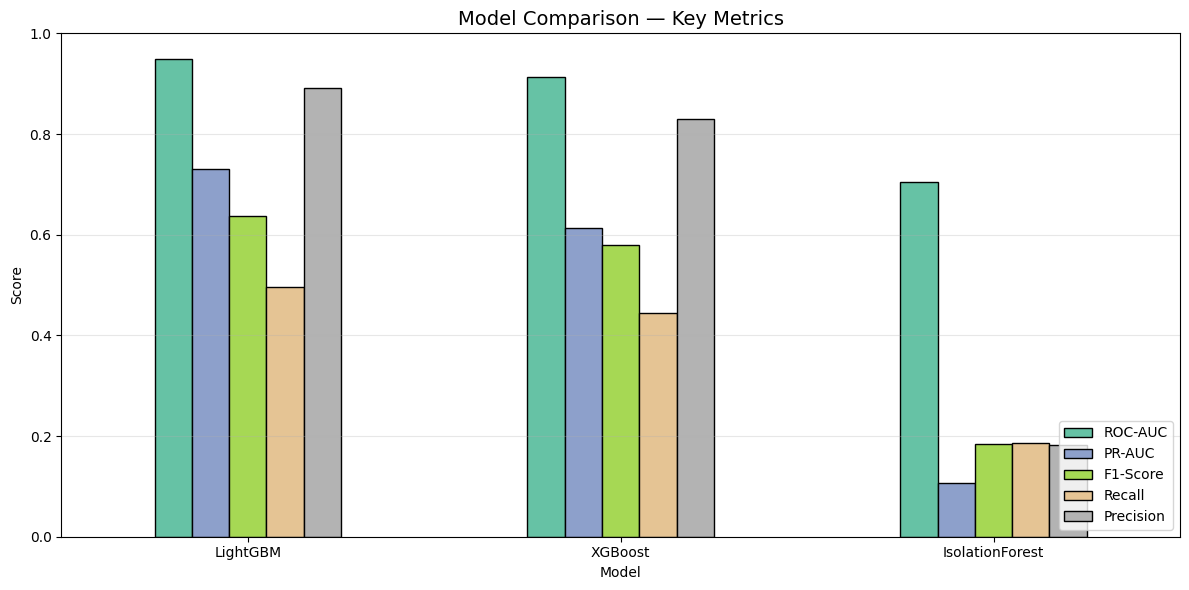

All charts saved!


In [20]:
fig, ax = plt.subplots(figsize=(12, 6))
results_df[['ROC-AUC','PR-AUC','F1-Score','Recall','Precision']].plot(
    kind='bar', ax=ax, colormap='Set2', edgecolor='black')
ax.set_title('Model Comparison — Key Metrics', fontsize=14)
ax.set_ylabel('Score'); ax.set_ylim(0, 1)
ax.set_xticklabels(results_df.index, rotation=0)
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('All charts saved!')